In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import statsmodels.api as sm

insurance_df = pd.read_csv("c:\\Users\\donat\\iCloudDrive\\Documents\\BIT Data Analytics\\practice\\VSCode\\data/insurance.csv") #.sample(500)

In [3]:
insurance_df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
insurance_df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1338.0,39.207025,14.049960,18.0000,27.00000,39.000,51.000000,64.00000
bmi,1338.0,30.663397,6.098187,15.9600,26.29625,30.400,34.693750,53.13000
children,1338.0,1.094918,1.205493,0.0000,0.00000,1.000,2.000000,5.00000
charges,1338.0,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


In [5]:
### Introducing Random columns will not decrease R-squared

# import numpy as np

# rng = np.random.default_rng(12345)

# insurance_df = insurance_df.assign(
#     rand_col = rng.random(len(insurance_df)),
#     rand_col2 = rng.random(len(insurance_df)),
#     rand_col3 = rng.random(len(insurance_df)),
# )

In [6]:
insurance_df.corr(numeric_only=True)

,age,bmi,children,charges
age,1.000000,0.109272,0.042469,0.299008
bmi,0.109272,1.000000,0.012759,0.198341
children,0.042469,0.012759,1.000000,0.067998
charges,0.299008,0.198341,0.067998,1.000000


<Axes: >

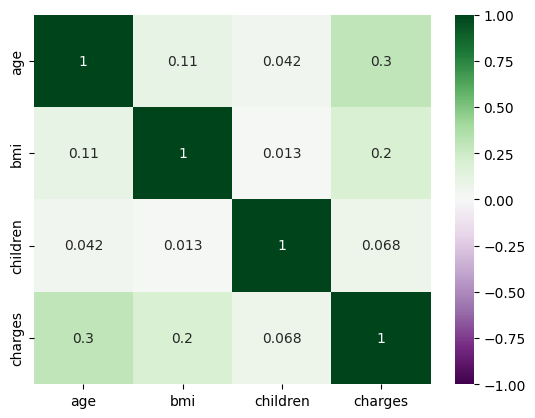

In [7]:
sns.heatmap(insurance_df.corr(numeric_only=True), annot=True, vmin=-1, vmax=1, cmap="PRGn")

In [8]:
features = ["age", "bmi"]
X = sm.add_constant(insurance_df[features])
y = insurance_df["charges"]

model = sm.OLS(y, X).fit()

model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                charges   R-squared:                       0.117
Model:                            OLS   Adj. R-squared:                  0.116
Method:                 Least Squares   F-statistic:                     88.60
Date:                Sat, 07 Mar 2026   Prob (F-statistic):           7.39e-37
Time:                        21:11:11   Log-Likelihood:                -14394.
No. Observations:                1338   AIC:                         2.879e+04
Df Residuals:                    1335   BIC:                         2.881e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -6424.8046   1744.091     -3.684      0.000   -9846.262   -3003.347
age          241.9308     22.298     10.850      0.000     198.187     285.674
bmi          332.9651     51.374      6.481      0.000     232.182     433.748
==============================================================================
Omnibus:                      321.874   Durbin-Watson:                   2.010
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              592.574
Skew:                           1.511   Prob(JB):                    2.11e-129
Kurtosis:                       4.223   Cond. No.                         287.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

charges auga - amzius - kas metus po 241,96; bmi - kas punktą - 332,96

In [9]:
features = ["age", "bmi", "children"]
X = sm.add_constant(insurance_df[features])
y = insurance_df["charges"]

model = sm.OLS(y, X).fit()

model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                charges   R-squared:                       0.120
Model:                            OLS   Adj. R-squared:                  0.118
Method:                 Least Squares   F-statistic:                     60.69
Date:                Sat, 07 Mar 2026   Prob (F-statistic):           8.80e-37
Time:                        21:11:11   Log-Likelihood:                -14392.
No. Observations:                1338   AIC:                         2.879e+04
Df Residuals:                    1334   BIC:                         2.881e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -6916.2433   1757.480     -3.935      0.000   -1.04e+04   -3468.518
age          239.9945     22.289     10.767      0.000     196.269     283.720
bmi          332.0834     51.310      6.472      0.000     231.425     432.741
children     542.8647    258.241      2.102      0.036      36.261    1049.468
==============================================================================
Omnibus:                      325.395   Durbin-Watson:                   2.012
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              603.372
Skew:                           1.520   Prob(JB):                    9.54e-132
Kurtosis:                       4.255   Cond. No.                         290.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Metrics

In [10]:
from sklearn.metrics import mean_absolute_error as mae
# from sklearn.metrics import mean_squared_error as rmse
from sklearn.metrics import r2_score as r2

from sklearn.metrics import root_mean_squared_error as rmse

print(f"MAE: {mae(y, model.predict())}")

print(f"RMSE: {rmse(y, model.predict())}")
print(f"R2: {r2(y, model.predict())}")


MAE: 9015.442199156727
RMSE: 11355.317901125973
R2: 0.12009819576246927


Tai yra regresijos modelio įvertinimo metrikos su **insurance** duomenimis,
kur target yra **draudimo išlaidos (charges)**.

**MAE = 9032.48**  
Vidutinė absoliuti klaida.  
Modelio prognozės vidutiniškai **klysta apie 9 032** išlaidų vienetus.

**RMSE = 11 374.11**  
Kvadratinės klaidos šaknis.  
Didelės klaidos čia „baudžiamos“ stipriau, todėl RMSE > MAE.  
Tipinė prognozės paklaida yra apie **11 374**.

**R² = 0.118**  
Modelis paaiškina tik apie **11.8 % draudimo išlaidų variacijos**.  
Didžioji dalis išlaidų skirtumų lieka **nepaaiškinta**.

**Interpretacija:**
- Modelis yra **silpnas aiškinimo ir prognozės prasme**.
- Prognozės klaidos yra didelės absoliučia verte.
- Tikėtina, kad:
  - neįtraukti svarbūs požymiai (pvz., rūkymas, amžius, KMI sąveikos),
  - ryšys nėra tiesinis,
  - reikalingos transformacijos (pvz., `log(charges)`),
  - arba modelis per daug supaprastintas.

**Išvada:**  
Esamas modelis **netinkamas tikslioms prognozėms**, kol nepatobulinamas.


<Axes: ylabel='None'>

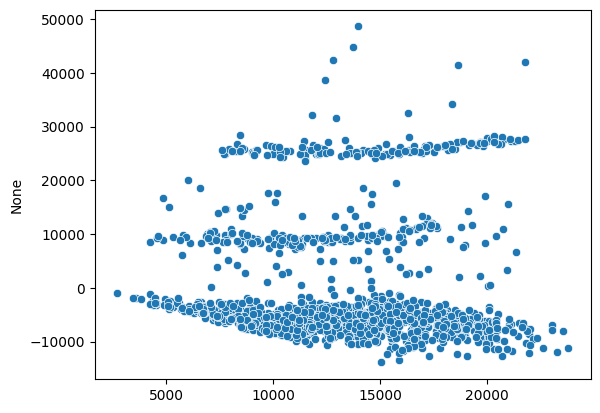

In [11]:
sns.scatterplot(x=model.predict(), y=model.resid)

Tai yra **insurance regresijos likučių (residuals) grafikas**, kuriame:
- x ašis – **modelio prognozuotos išlaidos (charges)**,
- y ašis – **likučiai** (tikra reikšmė − prognozė).

**Ką rodo šis vaizdas:**

- **Aiškios horizontalios juostos**  
Rodo, kad duomenys turi **skirtingas grupes** (pvz., rūkantieji / nerūkantieji), kurių modelis neatskiria. Tai ženklas, kad trūksta svarbaus kategorinio kintamojo arba sąveikų.

- **Didėjanti sklaida didėjant prognozei**  
Tai **heteroskedastiškumas** – klaidų dispersija nėra pastovi. Tiesinės regresijos prielaida pažeista.

- **Sisteminis raštas (ne atsitiktinis debesis)**  
Likučiai nėra „atsitiktinai išmėtyti“ aplink 0, todėl modelis **neaprašo ryšio tinkamai**.

- **Didelės teigiamos ir neigiamos klaidos**  
Modelis kai kuriais atvejais **stipriai pervertina arba nuvertina išlaidas**.

**Išvada:**
Šis grafikas rodo, kad **paprastas tiesinis modelis insurance duomenims yra netinkamas** dabartine forma.

**Ką tai reiškia praktiškai:**
- būtina įtraukti svarbius kintamuosius (ypač `smoker`);
- verta naudoti **log(charges)** transformaciją;
- gali prireikti sąveikų (pvz., `age × smoker`);
- kitaip tariant, problema yra **modelio specifikacijoje**, ne „triukšme“.
 
> Jei likučiai nėra atsitiktinis debesis apie nulį – modelis blogas.



### Making Predictions

In [14]:
new_data = pd.DataFrame({
    "age": [0, insurance_df["age"].min(), insurance_df["age"].mean(), insurance_df["age"].max()],
    "bmi": [0, insurance_df["bmi"].min(), insurance_df["bmi"].mean(), insurance_df["bmi"].max()],
})

new_data

,age,bmi
0,0.000000,0.000000
1,18.000000,15.960000
2,39.207025,30.663397
3,64.000000,53.130000


In [15]:
model.model.exog_names

['const', 'age', 'bmi', 'children']

In [13]:
X = sm.add_constant(new_data)

model.predict(X)

ValueError: shapes (4,3) and (4,) not aligned: 3 (dim 1) != 4 (dim 0)

In [ ]:
insurance_df = insurance_df.assign(
    smoker_flag=np.where(insurance_df["smoker"] == "yes", 1, 0),
    female_flag=np.where(insurance_df["sex"] == "female", 1, 0)
)
insurance_df

In [ ]:
# insurance_df = insurance_df.assign(
#     smoker_flag=np.where(insurance_df["smoker"] == "yes", 1, 0),
#     female_flag=np.where(insurance_df["sex"] == "female", 1, 0)
# )

X = sm.add_constant(insurance_df[["age", "bmi", "children", "smoker_flag"]])
y = insurance_df["charges"]

model = sm.OLS(y, X).fit()

model.summary()



**Modelio tinkamumas**
- **R² = 0.750** – modelis paaiškina apie **75 % draudimo išlaidų variacijos**.
- **Adjusted R² = 0.749** – įvertinus požymių skaičių, paaiškinama beveik tiek pat.
Tai rodo **gerą modelio kokybę**.

**Bendras modelio reikšmingumas**
- **F-statistic = 998.1**, **p-value ≈ 0.00**  
Modelis kaip visuma yra **statistiškai reikšmingas** (bent vienas požymis turi poveikį).

**Koeficientų interpretacija**
- **age = 257.85**  
Padidėjus amžiui 1 metais, draudimo išlaidos vidutiniškai **padidėja apie 258**, kai kiti veiksniai nekinta.
- **bmi = 321.85**  
Padidėjus BMI 1 vienetu, išlaidos vidutiniškai **padidėja apie 322**.
- **children = 473.50**  
Kiekvienas papildomas vaikas susijęs su **~474** didesnėmis išlaidomis.
- **smoker_flag = 23 810**  
Rūkymas padidina išlaidas vidutiniškai **apie 23 800**.  
Tai **stipriausias modelio veiksnys**.
- Visi koeficientai turi **p < 0.01**, todėl yra statistiškai reikšmingi.

**Interceptas (const)**
- Neigiamas ir neturi tiesioginės praktinės interpretacijos.
Jis rodo teorinę reikšmę, kai visi požymiai lygūs nuliui.

**Diagnostika**
- **Durbin–Watson ≈ 2.09** – nėra aiškios autokoreliacijos.
- **Omnibus / Jarque–Bera p ≈ 0** – likučiai **nėra normalūs**.
Tai dažna su `charges` dėl stiprios asimetrijos.
- **Cond. No. = 292** – galimas vidutinis kolinearumas, bet kritinės problemos nematyti.

**Išvada**
Tai **gerai sukalibruotas modelis**, kuris:
- labai gerai paaiškina `charges`,
- aiškiai parodo, kad **rūkymas yra dominuojantis išlaidų veiksnys**,
- vis dar pažeidžia normalumo prielaidą (galima svarstyti `log(charges)`).


In [ ]:
sns.scatterplot(x=model.predict(), y=model.resid).set(ylim=(-13000, 50000) )



- **X ašis** – modelio prognozuotos draudimo išlaidos (`predicted charges`).
- **Y ašis** – likučiai (`tikra reikšmė − prognozė`).

**Ką rodo grafikas:**

- **Aiškios atskiros juostos / grupės**  
Duomenys susiskaido į kelias grupes (tipiškai: nerūkantys ir rūkantys).  
Tai reiškia, kad modelis atpažįsta grupes, bet jų elgsena labai skiriasi.

- **Nevienoda klaidų sklaida (heteroskedastiškumas)**  
Didėjant prognozuotoms išlaidoms, klaidų dispersija didėja.  
Pažeidžiama tiesinės regresijos prielaida apie pastovią dispersiją.

- **Sisteminis raštas, ne atsitiktinis debesis**  
Likučiai nėra atsitiktinai išmėtyti aplink nulį, todėl ryšys nėra pilnai užfiksuotas tiesiniu modeliu.

- **Didelės teigiamos ir neigiamos klaidos**  
Kai kuriems atvejams modelis stipriai pervertina arba nuvertina išlaidas.

**Išvada:**
Nors R² yra aukštas, **modelio prielaidos nėra pilnai tenkinamos**.  
Tai rodo, kad:
- reikalinga `log(charges)` transformacija,
- verta pridėti sąveikas (pvz., `age × smoker`),
- arba naudoti alternatyvų modeliavimą.

**Trumpa taisyklė:**
Jei likučių grafike nėra „atsitiktinio debesies“ apie nulį – modelis struktūriškai netinkamas.


In [ ]:
# from sklearn.metrics import mean_absolute_error as mae
# from sklearn.metrics import mean_squared_error as rmse
# from sklearn.metrics import r2_score as r2

print(f"MAE: {mae(y, model.predict())}")
print(f"RMSE: {rmse(y, model.predict(), squared=False)}")
print(f"R2: {r2(y, model.predict())}")